<div align='center'>
    <h1>Tugas Besar Pembelajaran Mesin</h1>
    <h3>Judul: Klasifikasi Genre Video Game Berdasarkan Deskripsi Teks</h3>
</div>

---
<div align='center'>
    Membahas proses klasifikasi genre video game berdasarkan deskripsi teks menggunakan pendekatan supervised learning. Model yang digunakan meliputi baseline berbasis TF-IDF + Naive Bayes, TF-IDF + SVM, dan model berbasis BERT.
</div>

1. Import Library

In [ ]:
# Library dasar
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Library ML dasar
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

2. Upload Dataset

In [ ]:
# Upload file dari laptop
from google.colab import files
uploaded = files.upload()

Saving Dataset.csv to Dataset.csv


3. Load Data

In [ ]:
# Baca dataset
df = pd.read_csv('Dataset.csv')

In [ ]:
# Cek isi awal
df.head()

,Unnamed: 0,id,Descriptions,Genre,random_genre,cat_id
0,0,1,The ultimate thief is back! Tread softly as yo...,"['Adventure', 'Shooter', 'Simulator']",Simulator,12
1,1,2,Thief is a first-person stealth game that like...,"['Shooter', 'Sport']",Sport,13
2,2,3,"In the third instalment of the Thief series, m...",['Shooter'],Shooter,11
3,3,4,There is a rising tide of fear in The City. Ha...,"['Adventure', 'Shooter']",Adventure,0
4,4,5,Baldur's Gate is a fantasy role-playing video ...,['Role-playing(RPG)'],Role-playing(RPG),10


4. Data Understanding

In [ ]:
# Cek ukuran data
df.shape

(50000, 6)

In [ ]:
# Cek nama kolom
df.columns

Index(['Unnamed: 0', 'id', 'Descriptions', 'Genre', 'random_genre', 'cat_id'], dtype='object')

In [ ]:
# Cek tipe data dan null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    50000 non-null  int64 
 1   id            50000 non-null  int64 
 2   Descriptions  50000 non-null  object
 3   Genre         50000 non-null  object
 4   random_genre  50000 non-null  object
 5   cat_id        50000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 2.3+ MB


In [ ]:
# Cek nilai kosong
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Descriptions,0
Genre,0
random_genre,0
cat_id,0


In [ ]:
# Cek duplikat
df.duplicated().sum()

np.int64(0)

5. Pilih Kolom Utama

In [ ]:
# Tentukan kolom teks dan label
possible_text_cols = ['Descriptions', 'Description', 'description', 'text']
possible_label_cols = ['random_genre', 'Genre', 'genre']

text_col = next((c for c in possible_text_cols if c in df.columns), None)
label_col = next((c for c in possible_label_cols if c in df.columns), None)

print("Text column :", text_col)
print("Label column:", label_col)

assert text_col is not None, "Kolom teks tidak ditemukan."
assert label_col is not None, "Kolom label tidak ditemukan."

Text column : Descriptions
Label column: random_genre


6. Subset Data

In [ ]:
# Ambil kolom yang dipakai saja
df = df[[text_col, label_col]].copy()
df.head()

,Descriptions,random_genre
0,The ultimate thief is back! Tread softly as yo...,Simulator
1,Thief is a first-person stealth game that like...,Sport
2,"In the third instalment of the Thief series, m...",Shooter
3,There is a rising tide of fear in The City. Ha...,Adventure
4,Baldur's Gate is a fantasy role-playing video ...,Role-playing(RPG)


7. Data Cleaning

In [ ]:
# Hapus data kosong dan duplikat
df = df.dropna(subset=[text_col, label_col]).copy()
df = df.drop_duplicates().copy()

df.shape

(49552, 2)

In [ ]:
# Bersihkan teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df[text_col].apply(clean_text)
df[['clean_text', label_col]].head()

,clean_text,random_genre
0,the ultimate thief is back tread softly as you...,Simulator
1,thief is a first person stealth game that like...,Sport
2,in the third instalment of the thief series ma...,Shooter
3,there is a rising tide of fear in the city hat...,Adventure
4,baldur s gate is a fantasy role playing video ...,Role-playing(RPG)


In [ ]:
# Cek hasil cleaning
df[['clean_text', label_col]].sample(5, random_state=42)

,clean_text,random_genre
11826,fort apocalypse is a 2d multi directional scro...,Shooter
9302,welcome to vsevolod the awesome game of battle...,Indie
31437,tom clancy s rainbow six 3 raven shield is a 2...,Shooter
26941,your ship moves horizontally at the bottom of ...,Shooter
21590,get carnage it is a cruel fast hardcore and me...,Indie


8. Exploratory Data Analysis

In [ ]:
# Statistik dasar
print("Jumlah data:", len(df))
print("Jumlah genre unik:", df[label_col].nunique())

print("\n5 genre terbanyak:")
print(df[label_col].value_counts().head())

Jumlah data: 49552
Jumlah genre unik: 15

5 genre terbanyak:
random_genre
Adventure    8293
Indie        5418
Strategy     5411
Shooter      4365
Simulator    3934
Name: count, dtype: int64


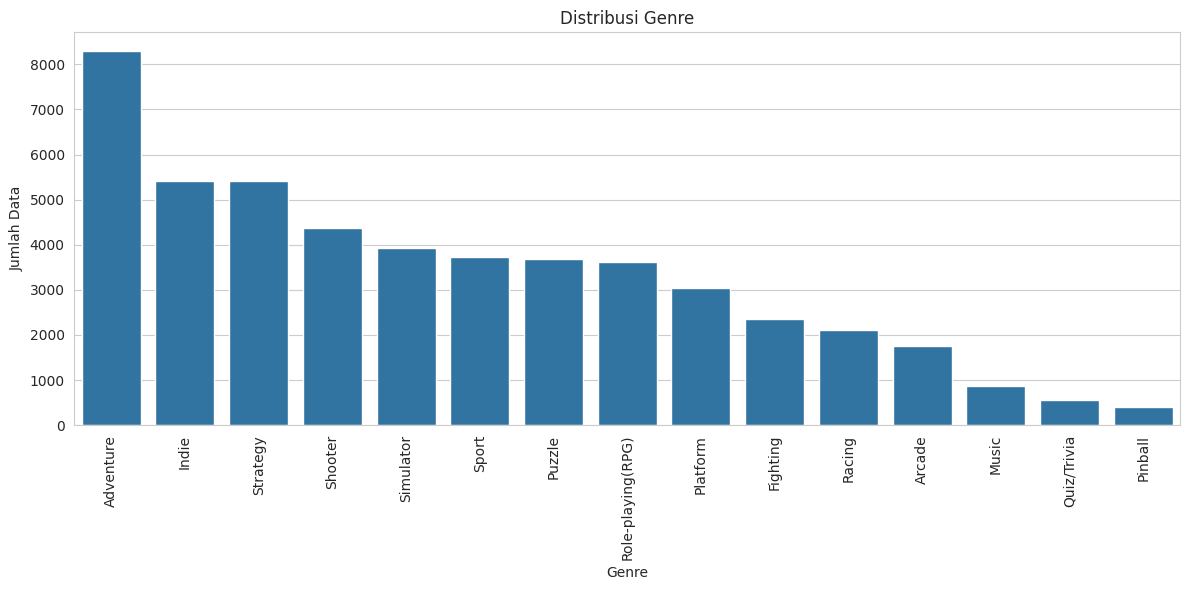

In [ ]:
# Distribusi label
plt.figure(figsize=(12, 6))
counts = df[label_col].value_counts()

sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=90)
plt.title('Distribusi Genre')
plt.xlabel('Genre')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

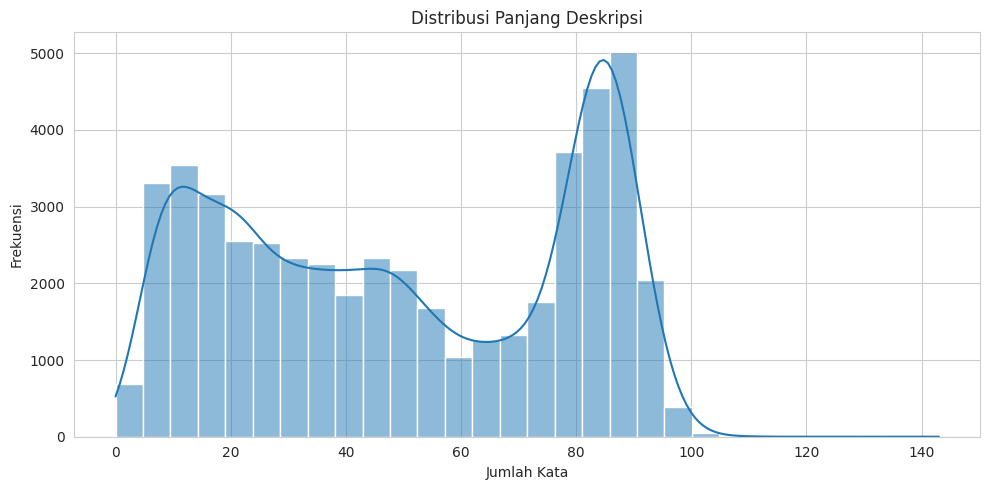

In [ ]:
# Panjang deskripsi
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Distribusi Panjang Deskripsi')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [ ]:
# Contoh data
df[['clean_text', label_col]].sample(5, random_state=1)

,clean_text,random_genre
29415,earth is under invasion by aliens and the only...,Pinball
45901,etherborn is an environmental puzzle platforme...,Adventure
20759,over 10 000 000 people worldwide are playing r...,Strategy
45682,the story of adelantado continues in book thre...,Adventure
49581,alder s blood is a grim dark and damp turn bas...,Role-playing(RPG)


9. Label Encoding

In [ ]:
# Ubah label ke angka
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[label_col])

label_mapping = pd.DataFrame({
    'label_asli': le.classes_,
    'label_encoded': range(len(le.classes_))
})

label_mapping

,label_asli,label_encoded
0,Adventure,0
1,Arcade,1
2,Fighting,2
3,Indie,3
4,Music,4
5,Pinball,5
6,Platform,6
7,Puzzle,7
8,Quiz/Trivia,8
9,Racing,9


10. Split Data

In [ ]:
# Pisah fitur dan target
X = df['clean_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (39641,)
Test : (9911,)


In [ ]:
# Split untuk BERT
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train BERT:", X_train_bert.shape)
print("Val BERT  :", X_val_bert.shape)

Train BERT: (35676,)
Val BERT  : (3965,)


**11. Model 1: TF-IDF + Naive Bayes**

In [ ]:
# Import untuk model klasik
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

In [ ]:
# Latih baseline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('clf', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
nb_pred = nb_pipeline.predict(X_test)

In [ ]:
# Fungsi evaluasi
def show_metrics(y_true, y_pred, model_name, label_names):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    print(f'=== {model_name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

results = []
results.append(show_metrics(y_test, nb_pred, 'TF-IDF + Naive Bayes', le.classes_))

=== TF-IDF + Naive Bayes ===
Accuracy : 0.4803
Precision: 0.5800
Recall   : 0.4279
F1-score : 0.4596

Classification Report:
                   precision    recall  f1-score   support

        Adventure       0.41      0.68      0.51      1659
           Arcade       0.44      0.05      0.10       350
         Fighting       0.71      0.42      0.53       473
            Indie       0.31      0.40      0.35      1084
            Music       0.83      0.57      0.68       174
          Pinball       0.94      0.40      0.56        80
         Platform       0.58      0.31      0.41       609
           Puzzle       0.52      0.43      0.47       739
      Quiz/Trivia       0.62      0.09      0.16       113
           Racing       0.71      0.59      0.64       421
Role-playing(RPG)       0.54      0.36      0.43       723
          Shooter       0.49      0.53      0.51       873
        Simulator       0.51      0.32      0.39       787
            Sport       0.57      0.75      0.65

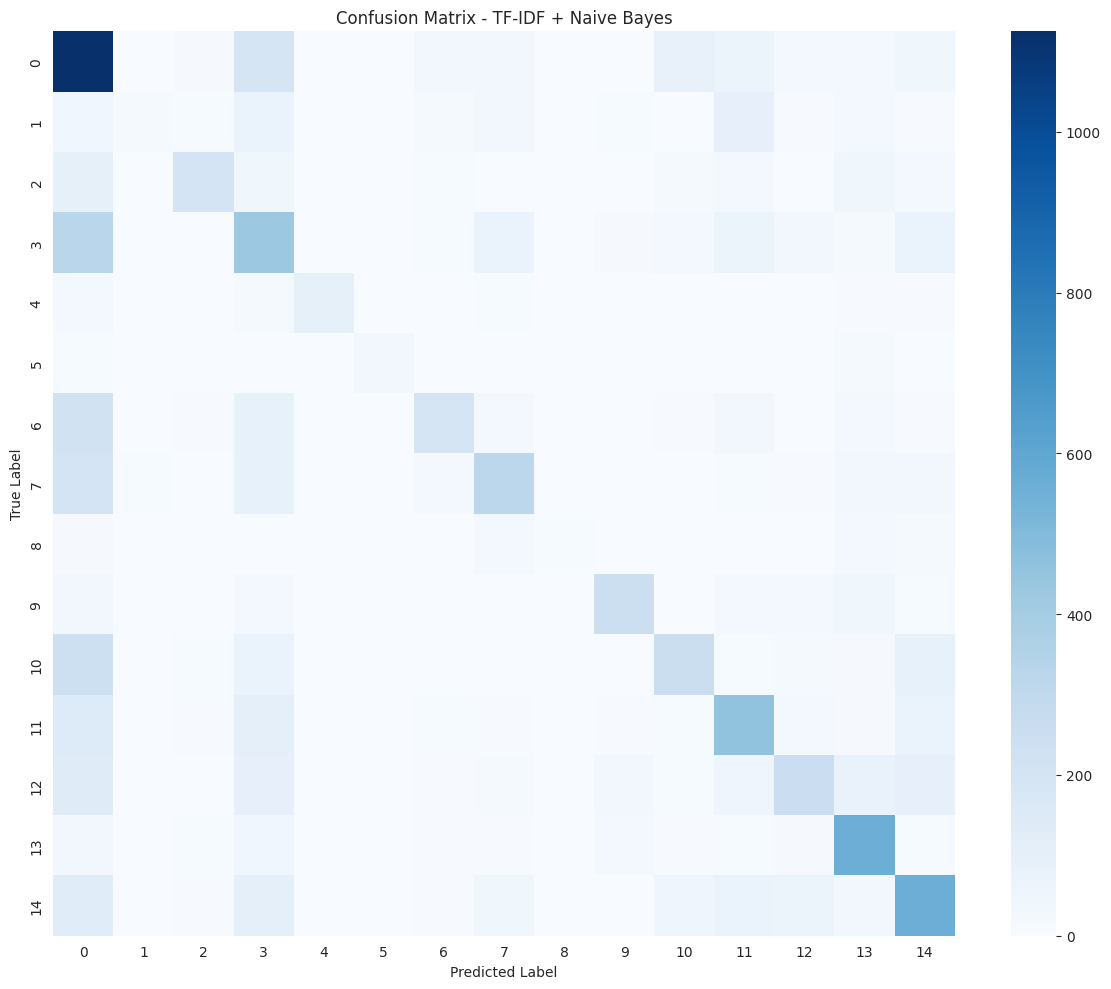

In [ ]:
# Confusion matrix
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_nb, cmap='Blues', cbar=True)
plt.title('Confusion Matrix - TF-IDF + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**12. Model 2: TF-IDF + SVM**

In [ ]:
# Import untuk tuning model
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

In [ ]:
# Siapkan pipeline SVM
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('clf', LinearSVC(class_weight='balanced'))
])

In [ ]:
# Cari setting terbaik
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.5, 1, 2]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)
print("Best Params:", grid_svm.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'clf__C': 0.5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}


In [ ]:
# Prediksi SVM terbaik
best_svm = grid_svm.best_estimator_
svm_pred = best_svm.predict(X_test)

results.append(show_metrics(y_test, svm_pred, 'TF-IDF + SVM', le.classes_))

=== TF-IDF + SVM ===
Accuracy : 0.4792
Precision: 0.4790
Recall   : 0.5292
F1-score : 0.4967

Classification Report:
                   precision    recall  f1-score   support

        Adventure       0.55      0.39      0.45      1659
           Arcade       0.19      0.23      0.21       350
         Fighting       0.50      0.62      0.55       473
            Indie       0.32      0.25      0.28      1084
            Music       0.61      0.80      0.69       174
          Pinball       0.64      0.68      0.66        80
         Platform       0.40      0.51      0.45       609
           Puzzle       0.48      0.51      0.49       739
      Quiz/Trivia       0.31      0.58      0.40       113
           Racing       0.59      0.71      0.64       421
Role-playing(RPG)       0.44      0.55      0.49       723
          Shooter       0.47      0.55      0.50       873
        Simulator       0.45      0.42      0.43       787
            Sport       0.68      0.69      0.68       7

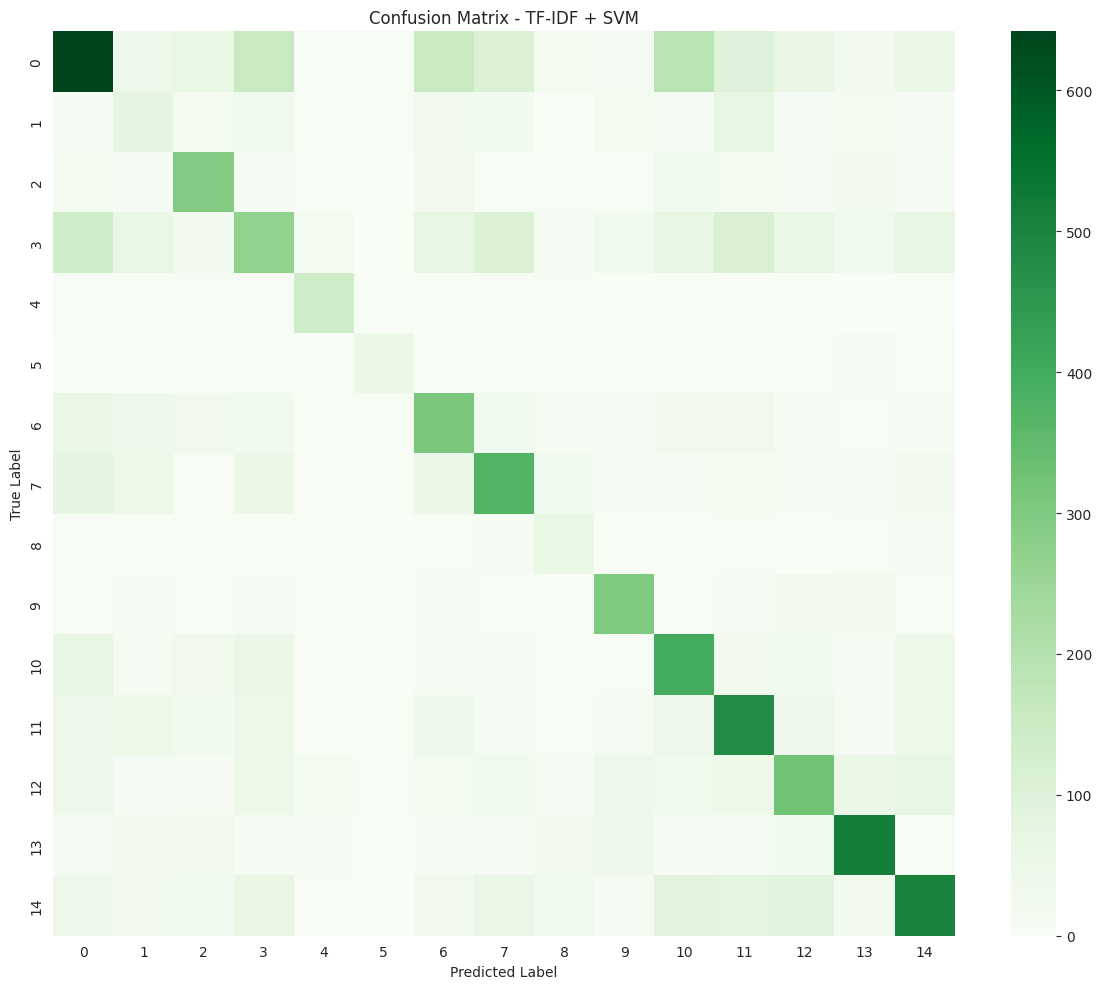

In [ ]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_svm, cmap='Greens', cbar=True)
plt.title('Confusion Matrix - TF-IDF + SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**13. Model 3: BERT**

In [ ]:
# Install library BERT
!pip -q install transformers datasets accelerate evaluate

In [ ]:
# Import BERT
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [ ]:
# Pilih checkpoint
checkpoint = 'bert-base-uncased'

In [ ]:
# Siapkan data untuk BERT
train_bert_df = pd.DataFrame({
    'text': X_train_bert.reset_index(drop=True),
    'labels': y_train_bert.reset_index(drop=True)
})

val_bert_df = pd.DataFrame({
    'text': X_val_bert.reset_index(drop=True),
    'labels': y_val_bert.reset_index(drop=True)
})

test_bert_df = pd.DataFrame({
    'text': X_test.reset_index(drop=True),
    'labels': y_test.reset_index(drop=True)
})

In [ ]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256)

In [ ]:
# Tokenisasi dataset
train_ds = HFDataset.from_pandas(train_bert_df, preserve_index=False).map(tokenize_function, batched=True)
val_ds = HFDataset.from_pandas(val_bert_df, preserve_index=False).map(tokenize_function, batched=True)
test_ds = HFDataset.from_pandas(test_bert_df, preserve_index=False).map(tokenize_function, batched=True)

Map:   0%|          | 0/35676 [00:00<?, ? examples/s]

Map:   0%|          | 0/3965 [00:00<?, ? examples/s]

Map:   0%|          | 0/9911 [00:00<?, ? examples/s]

In [ ]:
# Hapus kolom teks
train_ds = train_ds.remove_columns(['text'])
val_ds = val_ds.remove_columns(['text'])
test_ds = test_ds.remove_columns(['text'])

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Model klasifikasi
num_labels = df['label_encoded'].nunique()

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Fungsi metrik
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
# Atur training
training_args = TrainingArguments(
    output_dir='/content/bert_output',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy='epoch',

    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    save_total_limit=1,
    logging_steps=50,
    report_to='none'
)

In [ ]:
import transformers
print(transformers.__version__)

5.10.2


In [ ]:
import transformers
print(transformers.__file__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(output_dir='test')
print("OK")

OK


In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.397063,1.378742,0.561160,0.596739,0.576184,0.575324
2,1.090700,1.374013,0.562926,0.576545,0.589865,0.578086


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=8920, training_loss=1.3782676063845511, metrics={'train_runtime': 1598.6802, 'train_samples_per_second': 44.632, 'train_steps_per_second': 5.58, 'total_flos': 3632530231759608.0, 'train_loss': 1.3782676063845511, 'epoch': 2.0})

In [ ]:
# Evaluasi test set
bert_test_result = trainer.predict(test_ds)
bert_pred = np.argmax(bert_test_result.predictions, axis=-1)

results.append(show_metrics(y_test.values, bert_pred, 'BERT', le.classes_))

=== BERT ===
Accuracy : 0.5435
Precision: 0.5548
Recall   : 0.5593
F1-score : 0.5538

Classification Report:
                   precision    recall  f1-score   support

        Adventure       0.53      0.54      0.54      1659
           Arcade       0.30      0.15      0.20       350
         Fighting       0.58      0.64      0.61       473
            Indie       0.41      0.36      0.38      1084
            Music       0.72      0.79      0.75       174
          Pinball       0.76      0.69      0.72        80
         Platform       0.45      0.53      0.49       609
           Puzzle       0.56      0.52      0.54       739
      Quiz/Trivia       0.49      0.49      0.49       113
           Racing       0.65      0.71      0.68       421
Role-playing(RPG)       0.51      0.58      0.54       723
          Shooter       0.54      0.66      0.60       873
        Simulator       0.52      0.43      0.47       787
            Sport       0.71      0.75      0.73       744
     

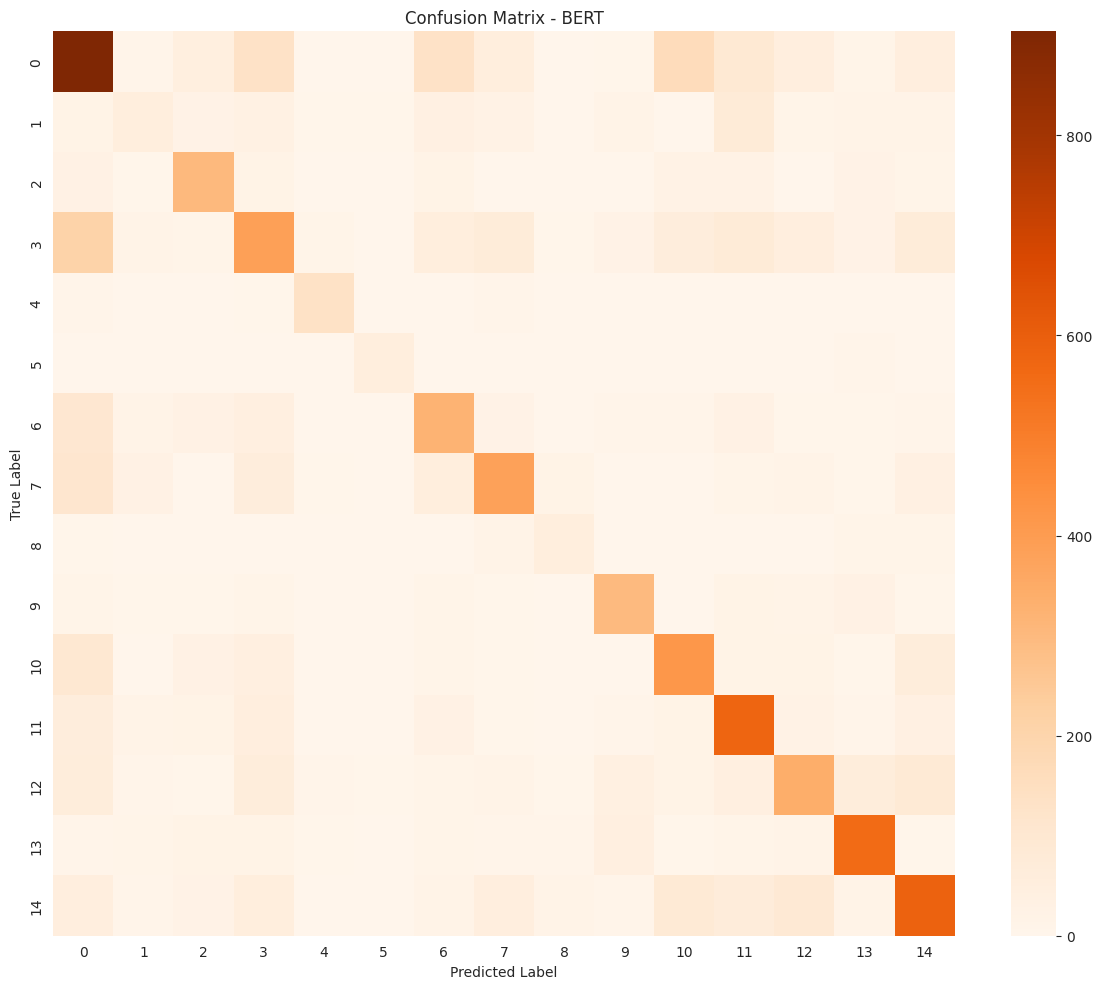

In [ ]:
# Confusion matrix
cm_bert = confusion_matrix(y_test, bert_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_bert, cmap='Oranges', cbar=True)
plt.title('Confusion Matrix - BERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

14. Perbandingan Hasil

In [ ]:
# Tabel hasil
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Naive Bayes,0.480274,0.580045,0.427886,0.459573
1,TF-IDF + SVM,0.479165,0.478984,0.529155,0.496683
2,BERT,0.543537,0.554830,0.559304,0.553805


In [ ]:
# Urutkan berdasarkan F1-score
results_df = results_df.sort_values(by='F1-score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score
2,BERT,0.543537,0.554830,0.559304,0.553805
1,TF-IDF + SVM,0.479165,0.478984,0.529155,0.496683
0,TF-IDF + Naive Bayes,0.480274,0.580045,0.427886,0.459573


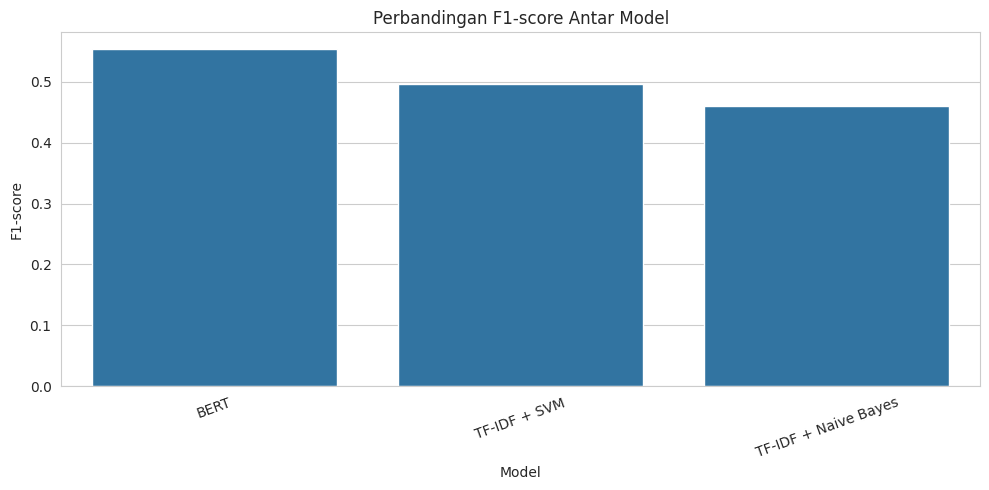

In [ ]:
# Grafik F1-score
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1-score')
plt.title('Perbandingan F1-score Antar Model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

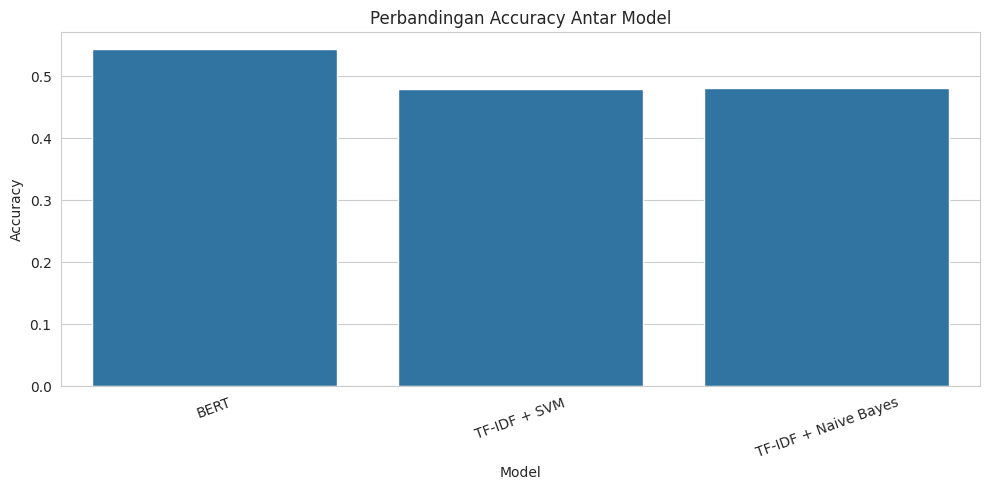

In [ ]:
# Grafik accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title('Perbandingan Accuracy Antar Model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# Simpan hasil
results_df.to_csv('model_comparison.csv', index=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score
2,BERT,0.543537,0.554830,0.559304,0.553805
1,TF-IDF + SVM,0.479165,0.478984,0.529155,0.496683
0,TF-IDF + Naive Bayes,0.480274,0.580045,0.427886,0.459573
